Homework 6
==========
<link rel="stylesheet" href="/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/02_Script/02_1_Function/styles.css">

>📌 Question 9.1
>Using the same crime data set uscrime.txt as in Question 8.2, apply Principal Component Analysis and then create a regression model using the first few principal components.  Specify your new model in terms of the original variables (not the principal components), and compare its quality to that of your solution to Question 8.2.  You can use the R function prcomp for PCA. (Note that to first scale the data, you can include scale. = TRUE to scale as part of the PCA function. Don’t forget that, to make a prediction for the new city, you’ll need to unscale the coefficients (i.e., do the scaling calculation in reverse)!).
</br>


In [133]:
library("kernlab")
library("kknn")
library("tidyr")
library("dplyr")
library("ggplot2")
library("plotly")
library("combinat")
library("ggplot2")


####Functions
read_data<-function(data.path = character()){
    # Reads the data from the given path and returns a data frame. In this case, the data is tab separated and has a header.
    data <- read.csv(data.path,header = TRUE,sep = "\t")
    return(data)

}
split_data<-function(data,split.ratio = numeric()){
    # Splits the data into training and testing sets based on the given split ratio. The split ratio is the proportion of the data that will be used for training.
    set.seed(123) # Setting seed for reproducibility
    sample_index <- sample(1:nrow(data), size = floor(split.ratio * nrow(data)))
    train_data <- data[sample_index, ]
    test_data <- data[-sample_index, ]
    return(list(train = train_data, test = test_data))
}
build_model<-function(train_data,target_variable){
    # Builds a linear regression model using the training data. The target variable is "Crime" and the predictors are all other variables in the dataset.
    model <- lm(target_variable, data = train_data)
   
    return(model)
}

'data.frame':	47 obs. of  16 variables:
 $ M     : num  15.1 14.3 14.2 13.6 14.1 12.1 12.7 13.1 15.7 14 ...
 $ So    : int  1 0 1 0 0 0 1 1 1 0 ...
 $ Ed    : num  9.1 11.3 8.9 12.1 12.1 11 11.1 10.9 9 11.8 ...
 $ Po1   : num  5.8 10.3 4.5 14.9 10.9 11.8 8.2 11.5 6.5 7.1 ...
 $ Po2   : num  5.6 9.5 4.4 14.1 10.1 11.5 7.9 10.9 6.2 6.8 ...
 $ LF    : num  0.51 0.583 0.533 0.577 0.591 0.547 0.519 0.542 0.553 0.632 ...
 $ M.F   : num  95 101.2 96.9 99.4 98.5 ...
 $ Pop   : int  33 13 18 157 18 25 4 50 39 7 ...
 $ NW    : num  30.1 10.2 21.9 8 3 4.4 13.9 17.9 28.6 1.5 ...
 $ U1    : num  0.108 0.096 0.094 0.102 0.091 0.084 0.097 0.079 0.081 0.1 ...
 $ U2    : num  4.1 3.6 3.3 3.9 2 2.9 3.8 3.5 2.8 2.4 ...
 $ Wealth: int  3940 5570 3180 6730 5780 6890 6200 4720 4210 5260 ...
 $ Ineq  : num  26.1 19.4 25 16.7 17.4 12.6 16.8 20.6 23.9 17.4 ...
 $ Prob  : num  0.0846 0.0296 0.0834 0.0158 0.0414 ...
 $ Time  : num  26.2 25.3 24.3 29.9 21.3 ...
 $ Crime : int  791 1635 578 1969 1234 682 963 1555 

Importance of components:
                          PC1    PC2    PC3     PC4     PC5     PC6    PC7
Standard deviation     2.3974 1.7111 1.3976 1.15841 1.04100 0.71480 0.5886
Proportion of Variance 0.3832 0.1952 0.1302 0.08946 0.07225 0.03406 0.0231
Cumulative Proportion  0.3832 0.5784 0.7086 0.79803 0.87028 0.90434 0.9274
                           PC8     PC9    PC10    PC11   PC12    PC13    PC14
Standard deviation     0.49413 0.48242 0.45369 0.43422 0.3049 0.26089 0.22752
Proportion of Variance 0.01628 0.01552 0.01372 0.01257 0.0062 0.00454 0.00345
Cumulative Proportion  0.94372 0.95923 0.97295 0.98552 0.9917 0.99626 0.99971
                          PC15
Standard deviation     0.06593
Proportion of Variance 0.00029
Cumulative Proportion  1.00000

[1] "sdev"     "rotation" "center"   "scale"    "x"

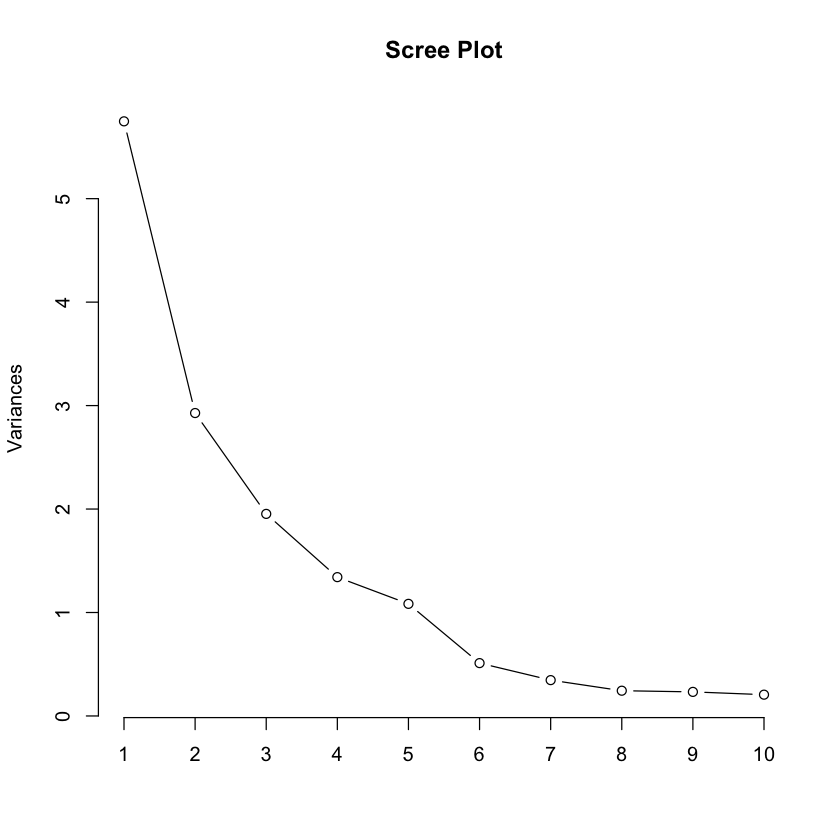

In [179]:
path_data_toread<-"/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/01_Data/Homework5_ISYE6501/uscrime.txt"

Crime_data_set <- read_data(path_data_toread)

# First lets examine the data set

str(Crime_data_set)

# Lets start playing with PCA Function

Crime_PCA <- prcomp(Crime_data_set[-1], scale. = TRUE)

# Lets see the summary of the PCA

summary(Crime_PCA)

# Lets see the loadings of the PCA

names(Crime_PCA)

screeplot(Crime_PCA, main = "Scree Plot", type = "line")


In [166]:
pcaCrime <-cbind(as.data.frame(Crime_PCA$x[,1:5]), data_frame(Crime_data_set[,15]))
colnames(pcaCrime)  <- c("PC1", "PC2", "PC3", "PC4", "PC5", "Crime")
regression_model <- build_model(train_data = pcaCrime, target_variable = Crime ~ .)

summary(regression_model)


Call:
lm(formula = target_variable, data = train_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-5.8957 -1.6208 -0.5264  1.3193  6.8741 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 26.59792    0.41208  64.546  < 2e-16 ***
PC1         -0.02696    0.17375  -0.155    0.877    
PC2          2.61430    0.24343  10.740 1.73e-13 ***
PC3          1.38798    0.29804   4.657 3.36e-05 ***
PC4          2.39330    0.35957   6.656 5.06e-08 ***
PC5          3.27820    0.40013   8.193 3.61e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.825 on 41 degrees of freedom
Multiple R-squared:  0.8584,	Adjusted R-squared:  0.8411 
F-statistic: 49.69 on 5 and 41 DF,  p-value: 2.438e-16


In [167]:

regression_model <- build_model(train_data = pcaCrime[,c("PC2", "PC3", "PC4", "PC5", "Crime")], target_variable = Crime ~ .)

summary(regression_model)


Call:
lm(formula = target_variable, data = train_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-5.8936 -1.6524 -0.5877  1.2879  6.8788 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  26.5979     0.4073  65.309  < 2e-16 ***
PC2           2.6143     0.2406  10.867 8.86e-14 ***
PC3           1.3880     0.2946   4.712 2.70e-05 ***
PC4           2.3933     0.3554   6.735 3.49e-08 ***
PC5           3.2782     0.3955   8.290 2.21e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.792 on 42 degrees of freedom
Multiple R-squared:  0.8583,	Adjusted R-squared:  0.8448 
F-statistic: 63.59 on 4 and 42 DF,  p-value: < 2.2e-16


In [169]:
# create one test data point to predict the crime rate using the regression model

test_df <- data.frame(
M = 14.0,
So = 0,
Ed = 10.0,
Po1 = 12.0,
Po2 = 15.5,
LF = 0.640,
M.F = 94.0,
Pop = 150,
NW = 1.1,
U1 = 0.120,
U2 = 3.6,
Wealth = 3200,
Ineq = 20.1,
Prob = 0.04,
Time = 39.0
)
test_df

M,So,Ed,Po1,Po2,LF,M.F,Pop,NW,U1,U2,Wealth,Ineq,Prob,Time
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
14,0,10,12,15.5,0.64,94,150,1.1,0.12,3.6,3200,20.1,0.04,39


In [175]:

c_hat <- coef(regression_model)          # length k+1 (intercept + k PCs)
c0    <- c_hat[1]
ck    <- c_hat[-1]               # PC coefficients (vector of length k)
k     <- length(ck)                 # number of PCs actually used

P_k   <- Crime_PCA$rotation[, 1:k]
b_scaled <- P_k %*% ck


In [204]:
sigma <- Crime_PCA$scale

mu    <- Crime_PCA$center

b <- b_scaled / sigma                    # elementwise division
b0 <- c0 - sum(b * mu)                   # adjusted intercept

b


So,-3.109812492
Ed,0.478183656
Po1,0.168312681
Po2,0.188677992
LF,4.484720475
M.F,-0.659183072
Pop,0.037249371
NW,-0.125211454
U1,-74.529599417
U2,-1.162385095
Wealth,0.001173770


In [205]:
new_city <- as.numeric(test_df)   # ensure order matches

pred_new <- as.numeric(b0 + sum(b[1:5,] * new_city))
pred_new

[1] 1887.68

In [212]:
Equation_Excluded_predictor<- Crime ~   Ed + Po1 + Ineq + Prob

regression_model_2 <- build_model(train_data = Crime_data_set, target_variable = Equation_Excluded_predictor)
summary(regression_model_2)
prediction_model_3 <- predict(regression_model_2, test_df)
prediction_model_3



Call:
lm(formula = target_variable, data = train_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-590.46 -101.00   13.33  133.50  438.54 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -3054.64     744.31  -4.104 0.000183 ***
Ed            151.87      45.78   3.318 0.001882 ** 
Po1           115.89      14.69   7.889 8.01e-10 ***
Ineq           79.58      14.60   5.450 2.44e-06 ***
Prob        -3686.30    1686.52  -2.186 0.034461 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 221.8 on 42 degrees of freedom
Multiple R-squared:  0.6998,	Adjusted R-squared:  0.6712 
F-statistic: 24.47 on 4 and 42 DF,  p-value: 1.667e-10


1 
1306.914